This is a small introduction about how to use the ToFPipeline.

In this example we will work with local data. Only the loading function varies a bit depending on the data source.

In [30]:
import importlib # For reloading modules during development
import ToFPipeline.ToFPipeline as ToFPipeline
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

#Set up matplotlib to use LaTeX for text rendering, with Computer Modern font
#Without it you get faster plots but some of the formatting breaks.

mpl.rcParams.update({
    # Do NOT use external LaTeX
    "text.usetex": True,

    # All normal text
    "font.family": "serif",
    "font.serif": ["Computer Modern"],
    "font.size": 12,
    # All math text
    "mathtext.fontset": "cm",
})



In [37]:
#Any time you load the ToFPipeline you need to load the config file if you want to use the settings set in the config file.
importlib.reload(ToFPipeline)
ToFPipeline.GlobalConfig.load("ToFPipeline/config.yaml")
runNo=1999

In [38]:
#Usually you can read the photon energy, and necessary parameters from the recorded data. In this example we have to add it manually.

raw = """
> |Photon Energy|daq_run|Ugap|Ushift
> |1300|2119|29.673|14
> |1300|2120|28.224|17
> |1300|2121|26.669|20
> |1300|2122|25.169|23
> |1290|2123|29.575|14
> |1290|2124|28.13|17
> |1290|2125|26.579|20
> |1290|2126|25.083|23
> |1280|2127|29.478|14
> |1280|2128|28.034|17
> |1280|2129|26.489|20
> |1280|2130|24.999|23
> |1270|2131|29.378|14
> |1270|2132|27.938|17
> |1270|2133|26.399|20
> |1270|2134|24.913|23
> |1260|2135|29.28|14
> |1260|2136|27.843|17
> |1260|2137|26.308|20
> |1260|2138|24.827|23
> |1250|2139|29.179|14
> |1250|2140|27.747|17
> |1250|2141|26.216|20
> |1250|2142|24.741|23
> |1240|2143|29.079|14
> |1240|2144|27.649|17
> |1240|2145|26.124|20
> |1240|2146|24.655|23
> |1230|2147|28.979|14
> |1230|2148|27.552|17
> |1230|2149|26.03|20
> |1230|2150|24.567|23
> |1230|2152|28.979|14
> |1230|2153|27.552|17
> |1230|2154|26.03|20
> |1230|2155|24.567|23
> |1220|2156|28.878|14
> |1220|2157|27.454|17
> |1220|2158|25.938|20
> |1220|2159|24.479|23
> |1210|2160|28.776|14
> |1210|2161|27.356|17
> |1210|2162|25.845|20
> |1210|2163|24.392|23
> |1200|2164|28.673|14
> |1200|2165|27.257|17
> |1200|2166|25.751|20
> |1200|2167|24.304|23
> |1190|2168|28.569|14
> |1190|2169|27.157|17
> |1190|2170|25.655|20
> |1190|2171|24.216|23
> |1180|2172|28.466|14
> |1180|2173|27.058|17
> |1180|2174|25.56|20
> |1180|2175|24.126|23
> |1170|2176|28.362|14
> |1170|2177|26.956|17
> |1170|2178|25.464|20
> |1170|2179|24.036|23
> |1160|2180|28.257|14
> |1160|2181|26.854|17
> |1160|2182|25.368|20
> |1160|2183|23.946|23
> |1150|2184|28.151|14
> |1150|2185|26.753|17
> |1150|2186|25.271|20
> |1150|2187|23.854|23
> |1140|2188|28.046|14
> |1140|2189|26.651|17
> |1140|2190|25.175|20
> |1140|2191|23.763|23
> |1130|2192|27.938|14
> |1130|2193|26.548|17
> |1130|2194|25.075|20
> |1130|2195|23.671|23
> |1120|2196|27.831|14
> |1120|2197|26.444|17
> |1120|2198|24.978|20
> |1120|2199|23.579|23
> |1110|2200|27.722|14
> |1110|2201|26.341|17
> |1110|2202|24.878|20
> |1110|2203|23.485|23
> |1100|2204|27.614|14
> |1100|2205|26.235|17
> |1100|2206|24.778|20
> |1100|2207|23.392|23
> |1090|2208|27.503|14
> |1090|2209|26.13|17
> |1090|2210|24.679|20
> |1090|2211|23.298|23
> |1080|2212|27.394|14
> |1080|2213|26.022|17
> |1080|2214|24.577|20
> |1080|2215|23.204|23
> |1070|2216|27.282|14
> |1070|2217|25.915|17
> |1070|2218|24.476|20
> |1070|2219|23.108|23
> |1060|2220|27.171|14
> |1060|2221|25.808|17
> |1060|2222|24.374|20
> |1060|2223|23.013|23
> |1050|2224|27.058|14
> |1050|2225|25.7|17
> |1050|2226|24.271|20
> |1050|2227|22.915|23
> |1040|2228|26.944|14
> |1040|2229|25.591|17
> |1040|2230|24.167|20
> |1040|2231|22.819|23
> |1030|2232|26.829|14
> |1030|2233|25.479|17
> |1030|2234|24.062|20
> |1030|2235|22.72|23
> |1020|2236|26.714|14
> |1020|2237|25.37|17
> |1020|2238|23.958|20
> |1020|2239|22.622|23
> |1010|2240|26.599|14
> |1010|2241|25.257|17
> |1010|2242|23.851|20
> |1010|2243|22.522|23
> |1000|2244|26.481|14
> |1000|2245|25.146|17
> |1000|2246|23.745|20
> |1000|2247|22.423|23
"""

In [39]:
#here we first load the data, then we find the peak and the angles of the ToFs to the results. The angles are already stored in the data.
#You can do the same with the photon energy, here I just set it to an arbitrary value because for this preliminary analysis we do not need the correct value.
#This is also a good spot to plot some of the data to check wether the peakfinder works as expected. 

widthFraction=0.5
data = ToFPipeline.NXSLoader("data").load(runNumbers=[runNo]).defaultPreprocessing(baselineRegion=[1500,1550]).sampleShift()
results = ToFPipeline.PeakFinder(data.data).stack().smooth().smooth().normalize().process(threshold=0.01,peakNo=1,roi=[50,200],widthFraction=widthFraction,symmetric=False,slopeLength=2, slopeStartHeight=0.75)#.dataframe()
#results.fitGaussians(useUpperHalf=False, roiWidthMultiplier=3.0)
#results.plotSingle(ToF=0,xmin=280,xmax=480,figsize=(4,5),showGaussianFit=False)
ToFPipeline.AuxFunc(results.results).addData(data.angles, key="Angles", axis="detector")

results.results["Photon Energy"] = 1000


Random trainId: 1999, pulseId: 0


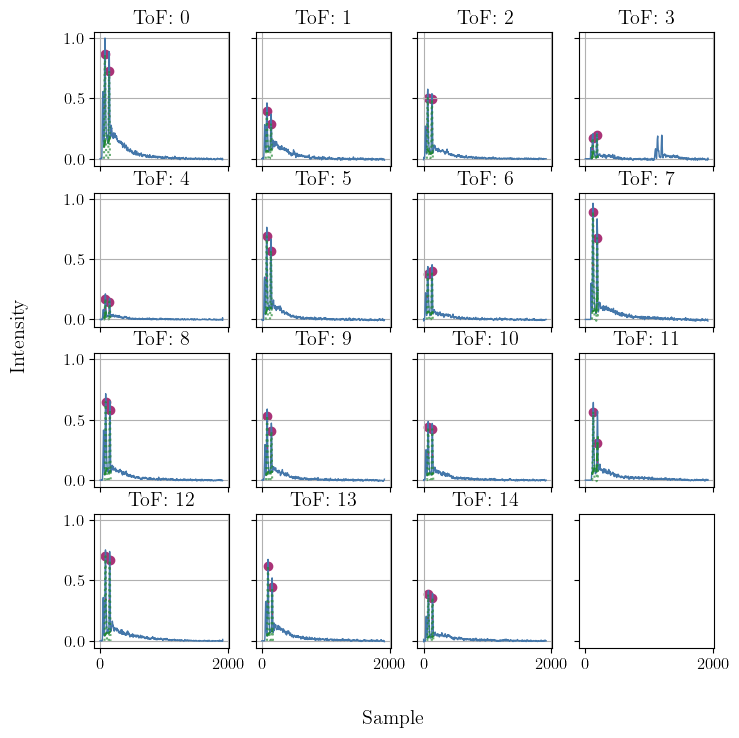

In [40]:
results.plot()

c:\Users\mogilows\Documents\PolScope\ToFPipeline\ToFPipeline.py:2284: RuntimeWarning: invalid value encountered in scalar divide
  (A_fit/P)**2 * sigma_A2 +
c:\Users\mogilows\Documents\PolScope\ToFPipeline\ToFPipeline.py:2285: RuntimeWarning: invalid value encountered in scalar divide
  (B_fit/P)**2 * sigma_B2 +
c:\Users\mogilows\Documents\PolScope\ToFPipeline\ToFPipeline.py:2286: RuntimeWarning: invalid value encountered in scalar divide
  2*(A_fit*B_fit/P**2)*sigma_AB
c:\Users\mogilows\Documents\PolScope\ToFPipeline\ToFPipeline.py:2289: RuntimeWarning: invalid value encountered in scalar divide
  (B_fit**2 * sigma_A2 + A_fit**2 * sigma_B2 - 2*A_fit*B_fit*sigma_AB)


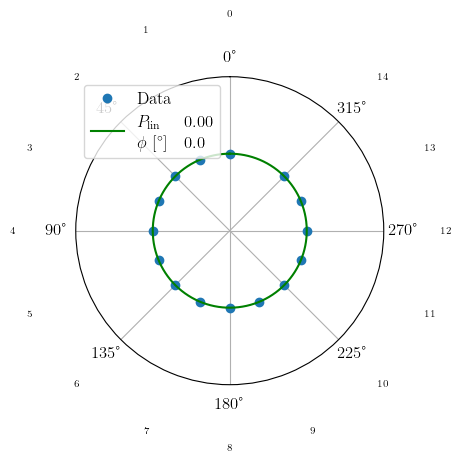

([np.float64(0.0), np.float64(0.0), np.float64(1.0)],
 [np.float64(nan), np.float64(nan), 0])

In [41]:
#In this cell the transmission calibration is performed. You need to know your beta value, degree of linear polarisation and which peak you want to calibrate on.
#Since we are at p04 and use circular polarised light to calibrate the beta value does not matter.
beta=1.27
pLin=0
peakNo=1
method = "height"
calib = ToFPipeline.Calibrate(results.results).transmission(peakNo=peakNo,setBeta=beta,setPlin=pLin,setPhi=0,intMethod=method).transmissionParam
ToFPipeline.Fitter(results.results).pol(transParam=calib,peakNo=peakNo,beta=beta,intMethod=method)

In [ ]:
# Here I parse the aux data of the runs I defined earlier.
import pandas as pd
from io import StringIO
rawdf = pd.read_csv(StringIO(raw), sep="|", skiprows=1).dropna().astype({"Photon Energy":int,"daq_run":int,"Ugap":float,"Ushift":float})
rawdf = rawdf[["daq_run","Photon Energy","Ugap","Ushift"]]

In [43]:
#The whole dataset is analysed here with a simple loop. When using the fitter it plots by default. Dont do it when analysing a lot of data.
#The results are then stored in a big dataframe. This way I can easily slice and plot across all runs.
import numpy as np
importlib.reload(ToFPipeline)
ToFPipeline.GlobalConfig.load("ToFPipeline/config.yaml")
values=[0]*len(rawdf["daq_run"].unique())
error=[0]*len(rawdf["daq_run"].unique())
energies=[0]*len(rawdf["daq_run"].unique())
daq_run=[0]*len(rawdf["daq_run"].unique())
beta=2
peakNo=1
method = method
first=True
j=0
for i in rawdf["daq_run"].unique():
    runNo = i
    setPhotonEnergy = rawdf[rawdf["daq_run"]==runNo]["Photon Energy"].values
    data = ToFPipeline.NXSLoader("data").load(runNumbers=[runNo],roi=[0,700]).defaultPreprocessing(baselineRegion=[0,10])
    results = ToFPipeline.PeakFinder(data.data).stack().smooth().smooth().normalize().process(threshold=0.005,slopeLength=2, slopeStartHeight=0.75,peakNo=peakNo,roi=[0,670],widthFraction=widthFraction)
    ToFPipeline.AuxFunc(results.results).addData(data.angles, key="Angles", axis="detector")
    setEnergyRun = {"daq_run": runNo, "Photon Energy": setPhotonEnergy}
    runsPhotonEnergy = pd.DataFrame(setEnergyRun)
    results.results["Photon Energy"] = setPhotonEnergy[0]
    popt,pcov = ToFPipeline.Fitter(results.results).pol(calib,peakNo=peakNo,beta=beta,plot=False,intMethod=method)
    values[j] = popt
    error[j] = pcov
    energies[j] = setPhotonEnergy[0]
    daq_run[j] = runNo
    if first:
        
        everything = results.results
        first=False
    else:
        everything = pd.concat([everything, results.results], ignore_index=True)
    j +=1
    print(f"Completed run {runNo}")
values=pd.DataFrame(values, columns=["PLin","phi","scale"])
values["Photon Energy"]=energies
values["daq_run"]=daq_run
error=pd.DataFrame(error, columns=["PLin_err","phi_err","scale_err"])
values["PLin_err"]=error["PLin_err"]
values["phi_err"]=error["phi_err"]
values["scale_err"]=error["scale_err"]



Completed run 2119
Completed run 2120
Completed run 2121
Completed run 2122
Completed run 2123
Completed run 2124
Completed run 2125
Completed run 2126
Completed run 2127
Completed run 2128
Completed run 2129
Completed run 2130
Completed run 2131
Completed run 2132
Completed run 2133
Completed run 2134
Completed run 2135
Completed run 2136
Completed run 2137
Completed run 2138
Completed run 2139
Completed run 2140
Completed run 2141
Completed run 2142
Completed run 2143
Completed run 2144
Completed run 2145
Completed run 2146
Completed run 2147
Completed run 2148
Completed run 2149
Completed run 2150
Completed run 2152
Completed run 2153
Completed run 2154
Completed run 2155
Completed run 2156
Completed run 2157
Completed run 2158
Completed run 2159
Completed run 2160
Completed run 2161
Completed run 2162
Completed run 2163
Completed run 2164
Completed run 2165
Completed run 2166
Completed run 2167
Completed run 2168
Completed run 2169
Completed run 2170
Completed run 2171
Completed ru

In [45]:
#Some run paramters are added to the results dataframe.
runTable = rawdf[["daq_run","Ugap","Ushift"]]
complete = values.merge(runTable, on="daq_run")

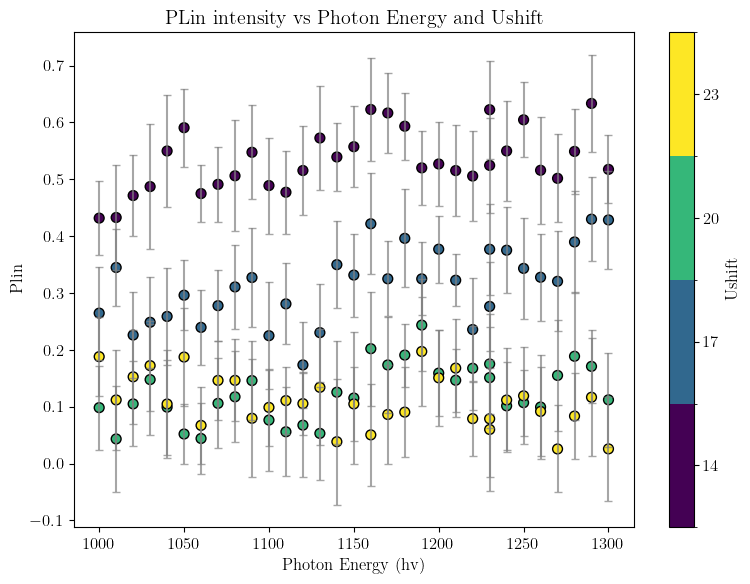

In [46]:
from matplotlib.colors import BoundaryNorm, ListedColormap
fig, ax = plt.subplots(figsize=(8, 6))

# Define the discrete color levels you want
levels = [14, 17, 20, 23]

# Create a colormap with exactly 4 colors
cmap = plt.get_cmap("viridis", len(levels))

# Create a norm that maps your data to the 4 discrete colors
# Boundaries need one more than levels
boundaries = [12.5, 15.5, 18.5, 21.5, 24.5]  # edges around your values
norm = BoundaryNorm(boundaries, cmap.N)

sc = ax.scatter(
    complete["Photon Energy"],          # x-axis
    complete["PLin"],      # y-axis
    c=complete["Ushift"],     # color = PL intensity
    cmap=cmap,    # choose any colormap
    norm=norm,
    s=50,              # marker size
    edgecolor="k"      # optional, black edge for clarity
)

plt.errorbar(
    complete["Photon Energy"],
    complete["PLin"],
    yerr=complete["PLin_err"],
    fmt='none',
    ecolor='gray',
    alpha=0.7,
    capsize=3
)

ax.set_xlabel("Photon Energy (hv)")
ax.set_ylabel("Plin")
ax.set_title("PLin intensity vs Photon Energy and Ushift")
#ax.invert_xaxis()  # common in spectroscopy


cbar = plt.colorbar(sc, ax=ax, ticks=levels)
cbar.set_label("Ushift")
plt.tight_layout()
plt.savefig("PLinVsUshift.png",dpi=600)
plt.show()



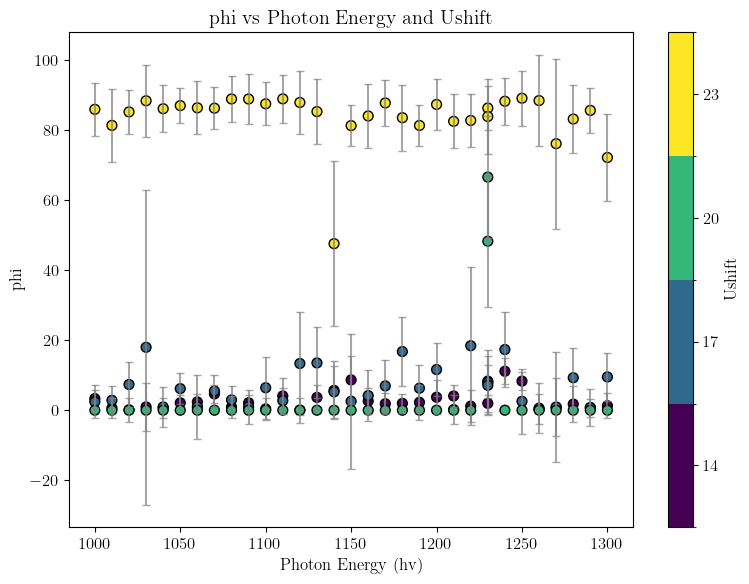

In [64]:
from matplotlib.colors import BoundaryNorm, ListedColormap
fig, ax = plt.subplots(figsize=(8, 6))

# Define the discrete color levels you want
levels = [14, 17, 20, 23]

# Create a colormap with exactly 4 colors
cmap = plt.get_cmap("viridis", len(levels))

# Create a norm that maps your data to the 4 discrete colors
# Boundaries need one more than levels
boundaries = [12.5, 15.5, 18.5, 21.5, 24.5]  # edges around your values
norm = BoundaryNorm(boundaries, cmap.N)

sc = ax.scatter(
    complete["Photon Energy"],          # x-axis
    abs(complete["phi"]),      # y-axis
    c=complete["Ushift"],     # color = PL intensity
    cmap=cmap,    # choose any colormap
    norm=norm,
    s=50,              # marker size
    edgecolor="k"      # optional, black edge for clarity
)

plt.errorbar(
    complete["Photon Energy"],
    abs(complete["phi"]),
    yerr=complete["phi_err"],
    fmt='none',
    ecolor='gray',
    alpha=0.7,
    capsize=3
)

ax.set_xlabel("Photon Energy (hv)")
ax.set_ylabel("phi")
ax.set_title("phi vs Photon Energy and Ushift")
#ax.set_ylim(-10, 100)
#ax.invert_xaxis()  # common in spectroscopy


cbar = plt.colorbar(sc, ax=ax, ticks=levels)
cbar.set_label("Ushift")
plt.tight_layout()
plt.savefig("phiVsUshift.png",dpi=600)
plt.show()



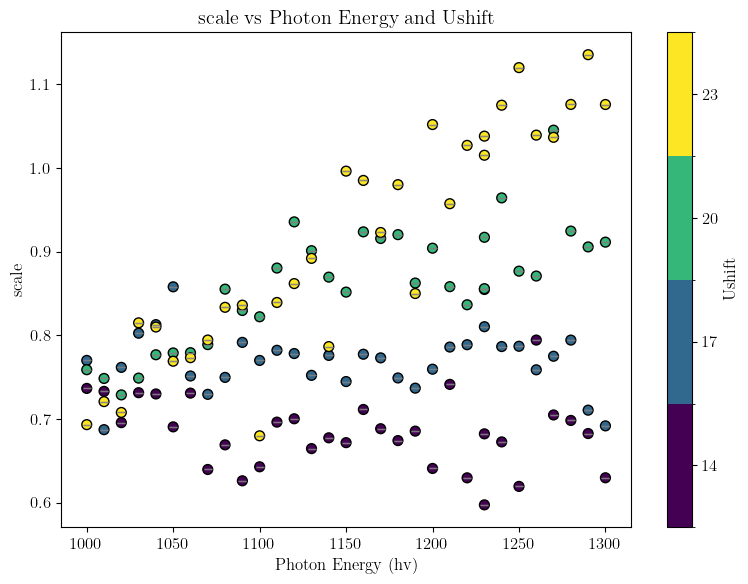

In [18]:
from matplotlib.colors import BoundaryNorm, ListedColormap
fig, ax = plt.subplots(figsize=(8, 6))

# Define the discrete color levels you want
levels = [14, 17, 20, 23]

# Create a colormap with exactly 4 colors
cmap = plt.get_cmap("viridis", len(levels))

# Create a norm that maps your data to the 4 discrete colors
# Boundaries need one more than levels
boundaries = [12.5, 15.5, 18.5, 21.5, 24.5]  # edges around your values
norm = BoundaryNorm(boundaries, cmap.N)

sc = ax.scatter(
    complete["Photon Energy"],          # x-axis
    complete["scale"],      # y-axis
    c=complete["Ushift"],     # color = PL intensity
    cmap=cmap,    # choose any colormap
    norm=norm,
    s=50,              # marker size
    edgecolor="k"      # optional, black edge for clarity
)

plt.errorbar(
    complete["Photon Energy"],
    complete["scale"],
    yerr=complete["scale_err"],
    fmt='none',
    ecolor='gray',
    alpha=0.7,
    capsize=3
)

ax.set_xlabel("Photon Energy (hv)")
ax.set_ylabel("scale")
ax.set_title("scale vs Photon Energy and Ushift")
#ax.set_ylim(-1,1)
#ax.invert_xaxis()  # common in spectroscopy


cbar = plt.colorbar(sc, ax=ax, ticks=levels)
cbar.set_label("Ushift")
plt.tight_layout()
plt.savefig("scaleVsUshift.png",dpi=600)
plt.show()



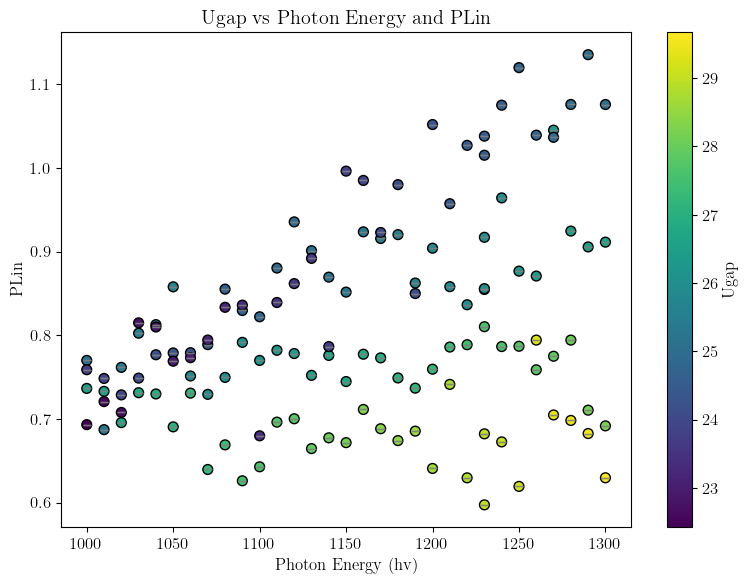

In [19]:
fig, ax = plt.subplots(figsize=(8, 6))

sc = ax.scatter(
    complete["Photon Energy"],          # x-axis
    complete["scale"],      # y-axis
    c=complete["Ugap"],     # color = PL intensity
    cmap="viridis",    # choose any colormap
    s=50,              # marker size
    edgecolor="k"      # optional, black edge for clarity
)
plt.errorbar(
    complete["Photon Energy"],
    complete["scale"],
    yerr=complete["scale_err"],
    fmt='none',
    ecolor='gray',
    alpha=0.7,
    capsize=3
)

ax.set_xlabel("Photon Energy (hv)")
ax.set_ylabel("PLin")
ax.set_title("Ugap vs Photon Energy and PLin")
#ax.invert_xaxis()  # common in spectroscopy

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Ugap")
plt.tight_layout()
plt.show()

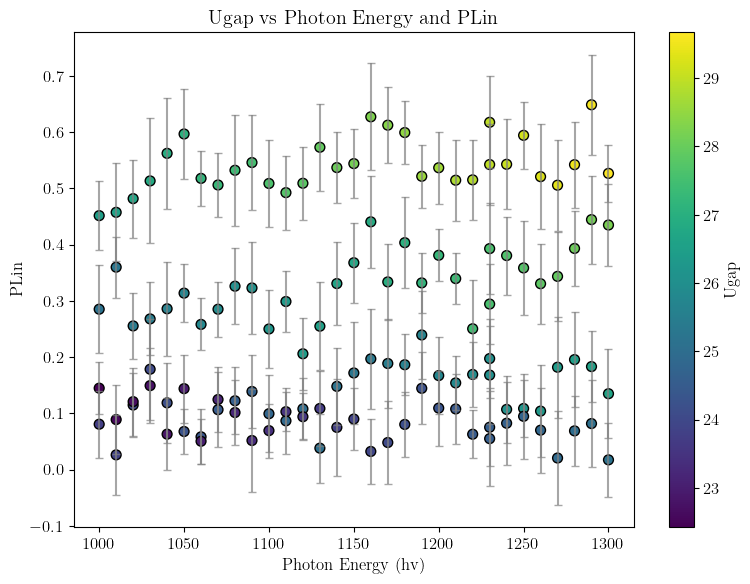

In [20]:
fig, ax = plt.subplots(figsize=(8, 6))

sc = ax.scatter(
    complete["Photon Energy"],          # x-axis
    complete["PLin"],      # y-axis
    c=complete["Ugap"],     # color = PL intensity
    cmap="viridis",    # choose any colormap
    s=50,              # marker size
    edgecolor="k"      # optional, black edge for clarity
)
plt.errorbar(
    complete["Photon Energy"],
    complete["PLin"],
    yerr=complete["PLin_err"],
    fmt='none',
    ecolor='gray',
    alpha=0.7,
    capsize=3
)

ax.set_xlabel("Photon Energy (hv)")
ax.set_ylabel("PLin")
ax.set_title("Ugap vs Photon Energy and PLin")
#ax.invert_xaxis()  # common in spectroscopy

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Ugap")
plt.tight_layout()
plt.show()

In [ ]:
merged = everything.merge(complete, on="trainId", how="left")
merged = merged.rename(columns={"Photon Energy_x":"Photon Energy"})


,detector,trainId,pulseId,peakNo,pos,height,width left,width right,fwhm area,baseline left,...,Photon Energy,PLin,phi,scale,Photon Energy_y,PLin_err,phi_err,scale_err,Ugap,Ushift


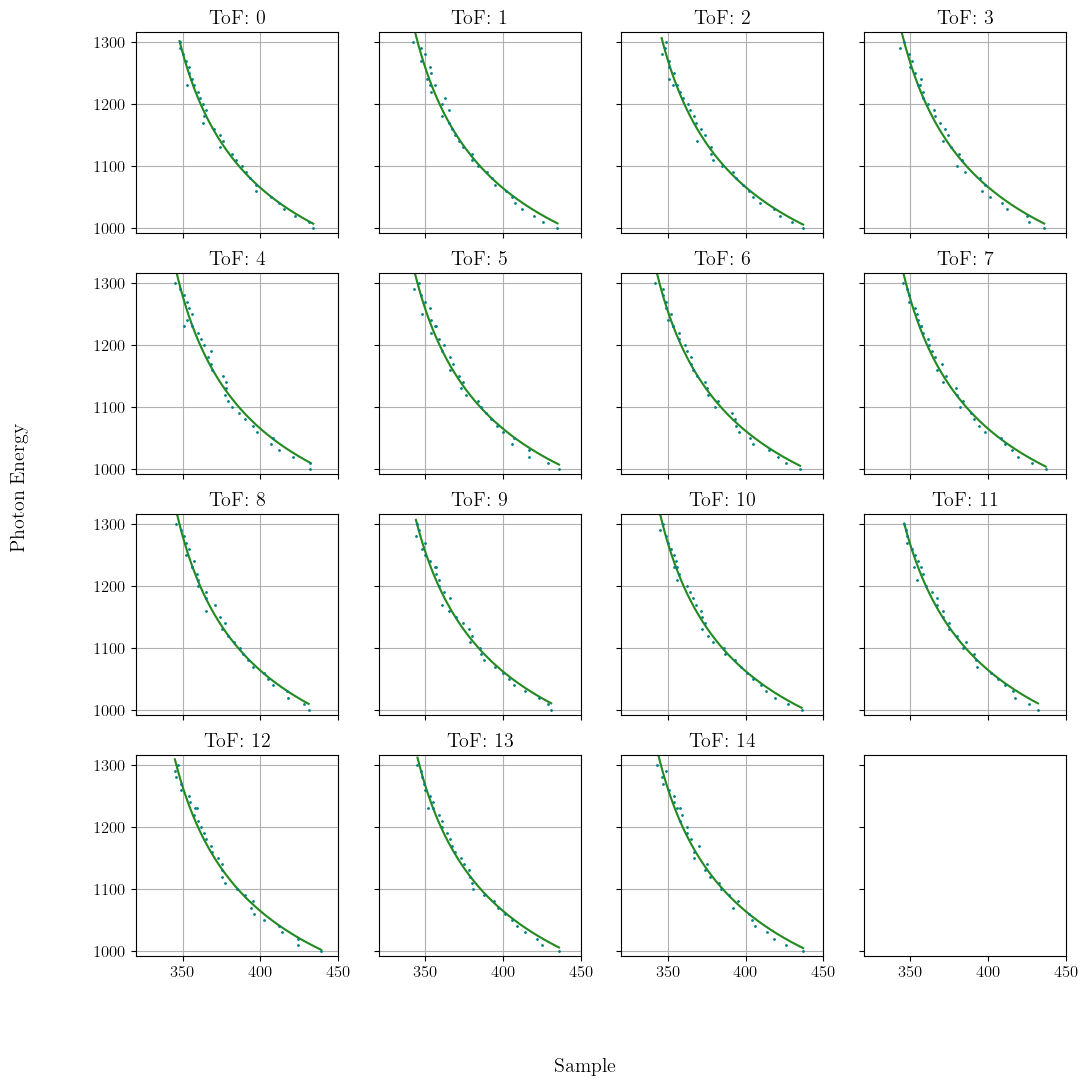

In [46]:
Ushift21 = merged[merged["Ushift"]==20]
ToFPipeline.Calibrate(Ushift21).energy(relPos=False).plotEnergy(xmin=320,xmax=450)

In [501]:
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

def polarization_model(theta, Plin=1, phi=0, beta2=2, scale=1):
    return scale*(1 + (beta2 / 4) * (1 + 3 * Plin * np.cos(2 * (theta - phi))))

def plotPol(results, transParam, peakNo=None,beta=0,intMethod="fwhm area"):
        peakNo = peakNo if peakNo is not None else self.config.get("peakNo", 0)
        
        fig, ax = plt.subplots(figsize=(6,4), subplot_kw={'projection': 'polar'})
        fullTheta = np.linspace(0,2*np.pi,16,endpoint=False)
        area = results[results["peakNo"]==peakNo][["fwhm area","height","detector","Angles"]]
        calib = [transParam]
        calibArea = pd.merge(area,calib,on="detector")
        calibArea["calibValue"] = calibArea[intMethod] * calibArea["Transmission Coefficent"] / calibArea[intMethod].max()
            
        theta = calibArea["Angles"].values*np.pi/180
        trace = calibArea["calibValue"].values
        #ax.set_rlim(0,2)
        ax.plot(theta, trace, marker="o", linewidth=0, label='Data')
    
        def model(theta,Plin,phi,scale):
            return polarization_model(theta, Plin, phi, beta2=beta, scale=scale)
            
        initial_guess = [0.5, 0.0,1.0]  # [Plin, phi, scale]
        bounds = ([0, -np.pi,0], [2, np.pi,20])
        popt, pcov = curve_fit(model, theta, trace, p0=initial_guess, bounds=bounds)
        Plin_fit, phi_fit, scale_fit = popt
    
        theta_fit = np.linspace(0, 2*np.pi, 360)
        intensity_fit = model(theta_fit, Plin_fit, phi_fit, scale=scale_fit)
        
        #ax.set_rlim(0,1.2)
        if Plin_fit>0.015:
            ax.plot([phi_fit,phi_fit],[0,1],color="orange")
            ax.plot([phi_fit+np.pi,phi_fit+np.pi],[0,1],color="orange")
        ax.plot(theta_fit, intensity_fit, label=f"Fitted degree of linear polarization: {Plin_fit:.5f}",color="green")
            
        ax.set_yticks([])
        ax.set_theta_zero_location("E")  # 0° at top
        ax.set_theta_direction(1)       # clockwise
        ax.legend(loc="lower right")
        plt.savefig("polPlots.png", dpi=600)
        plt.show()

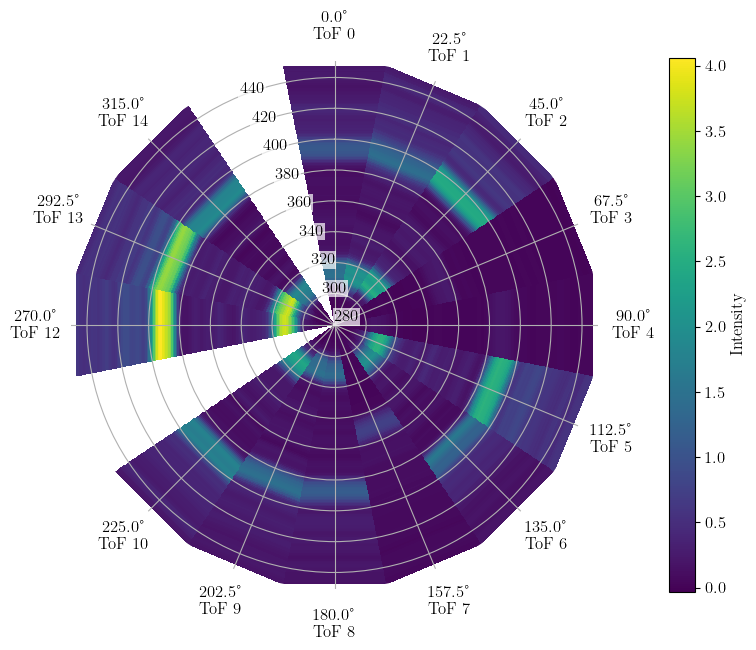

In [513]:
importlib.reload(ToFPipeline)
ToFPipeline.GlobalConfig.load("ToFPipeline/config.yaml")
data = ToFPipeline.NXSLoader("data").load(runNumbers=[2219]).defaultPreprocessing(baselineRegion=[0,10])
toPlot = ToFPipeline.PeakFinder(data.data).stack().smooth().smooth().normalize()
results = toPlot.process(threshold=0.01,peakNo=1,roi=[0,700],minWidth=False,symmetric=False,slopeLength=False, slopeStartHeight=False).dataframe()
ToFPipeline.AuxFunc(results.results).addData(data.angles, key="Angles", axis="detector")
results.results["Photon Energy"] = 1000
plotter = ToFPipeline.Plotter(data = toPlot.data)
plotter.plot(transParam=calib,sampleMin=280, sampleMax=450, interpolate=False)


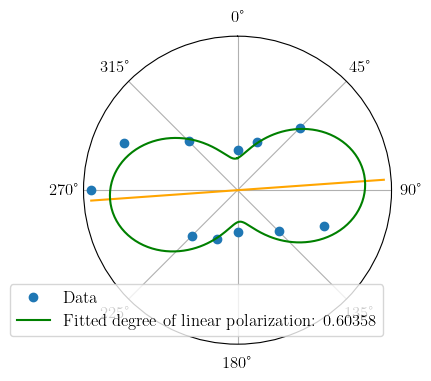

(array([ 0.60357617, -1.64182933,  1.4715748 ]),
 array([[ 0.00881577, -0.00185362, -0.00166279],
        [-0.00185362,  0.00393618, -0.00016441],
        [-0.00166279, -0.00016441,  0.00671788]]))

In [514]:
ToFPipeline.Fitter.pol(results, transParam=calib, peakNo=1,beta=2,intMethod="height")